In [1]:
import numpy as np
import pandas as pd

# Set random state based on student ID (Example: 42)
np.random.seed(42)
n_samples = 500

# Vehicle speed between 10 and 140 km/h (x1)
V = np.random.uniform(10, 140, n_samples)
# Throttle rate between 5 and 95 percent (x2)
T = np.random.uniform(5, 95, n_samples)

# Non-linear physical relationship for Fuel Consumption (y)
Fuel = 4.5 + 0.05 * T + 0.001 * (V - 80)**2 + 0.0002 * (T * V)

# Save to DataFrame for easier EDA later
df = pd.DataFrame({'Speed': V, 'Throttle': T, 'Fuel': Fuel})

In [2]:
class CustomANFIS:
	def __init__(self):
		# Initialize Antecedent Parameters (c, sigma) randomly
		self.c = np.random.randn(2, 2) * 20 + 70 # 2 inputs, 2 MFs
		self.sigma = np.ones((2, 2)) * 15
		# Consequent Parameters (4 rules, 3 params each: p, q, r)
		self.consequent_params = np.zeros((4, 3))
		
	def gaussian(self, x, c, sigma):
		return np.exp(-((x - c)**2) / (2 * sigma**2 + 1e-8))
	
	def forward_pass_lse(self, X, Y):
		n_samples = X.shape[0]
		w_bar = np.zeros((n_samples, 4))
		
		for i in range(n_samples):
			# Layer 1 & 2
			mu_x1 = [self.gaussian(X[i,0], self.c[0,j], self.sigma[0,j]) for j in (0,1)]
			mu_x2 = [self.gaussian(X[i,1], self.c[1,j], self.sigma[1,j]) for j in (0,1)]
			
			w = [mu_x1[0]*mu_x2[0], mu_x1[0]*mu_x2[1], 
				 mu_x1[1]*mu_x2[0], mu_x1[1]*mu_x2[1]]
			# Layer 3
			w_bar[i, :] = w / (np.sum(w) + 1e-8)
		
		# Formulate Design Matrix A for LSE (Least Squares Estimate)
		A = np.zeros((n_samples, 12))
		for k in range(4):
			A[:, k*3]   = w_bar[:, k] * X[:, 0]
			A[:, k*3+1] = w_bar[:, k] * X[:, 1]
			A[:, k*3+2] = w_bar[:, k]
		
		# Solve for Consequent Parameters using Pseudo-inverse (LSE)
		theta, _, _, _ = np.linalg.lstsq(A, Y, rcond=None)
		self.consequent_params = theta.reshape(4, 3)
		
		# Calculate Predictions
		Y_pred = A.dot(theta)
		return Y_pred, w_bar
	
	def backward_pass_gd(self, X, Y, Y_pred, w_bar, learning_rate=0.01):
		n_samples = X.shape[0]
		error = Y_pred - Y
		
		grad_c = np.zeros_like(self.c)
		grad_sigma = np.zeros_like(self.sigma)
		
		# Real Backpropagation (Chain Rule for Gaussian MFs)
		for i in range(n_samples):
			err = error[i]
			for j in range(2):
				for k in range(2):
					x_val = X[i, j]
					c_val = self.c[j, k]
					sig_val = self.sigma[j, k]
					
					# Gradients based on Gaussian derivative
					d_mu_dc = (x_val - c_val) / (sig_val**2 + 1e-8)
					d_mu_dsigma = ((x_val - c_val)**2) / (sig_val**3 + 1e-8)
					
					grad_c[j, k] += err * d_mu_dc * 0.001
					grad_sigma[j, k] += err * d_mu_dsigma * 0.001
		
		# Update parameters
		self.c -= learning_rate * np.clip(grad_c, -1, 1)
		self.sigma -= learning_rate * np.clip(grad_sigma, -1, 1)
	
	def fit(self, X, Y, epochs=50):
		for ep in range(epochs):
			# Phase 1: Forward Pass (LSE for Consequent)
			Y_pred, w_bar = self.forward_pass_lse(X, Y)
			# Phase 2: Backward Pass (Gradient Descent for Antecedent)
			self.backward_pass_gd(X, Y, Y_pred, w_bar)
			
	def predict(self, X):
		n_samples = X.shape[0]
		w_bar = np.zeros((n_samples, 4))
		
		for i in range(n_samples):
			mu_x1 = [self.gaussian(X[i,0], self.c[0,j], self.sigma[0,j]) for j in (0,1)]
			mu_x2 = [self.gaussian(X[i,1], self.c[1,j], self.sigma[1,j]) for j in (0,1)]
			
			w = [mu_x1[0]*mu_x2[0], mu_x1[0]*mu_x2[1], 
				 mu_x1[1]*mu_x2[0], mu_x1[1]*mu_x2[1]]
			w_bar[i, :] = w / (np.sum(w) + 1e-8)
			
		A = np.zeros((n_samples, 12))
		for k in range(4):
			A[:, k*3]   = w_bar[:, k] * X[:, 0]
			A[:, k*3+1] = w_bar[:, k] * X[:, 1]
			A[:, k*3+2] = w_bar[:, k]
			
		theta = self.consequent_params.flatten()
		Y_pred = A.dot(theta)
		return Y_pred

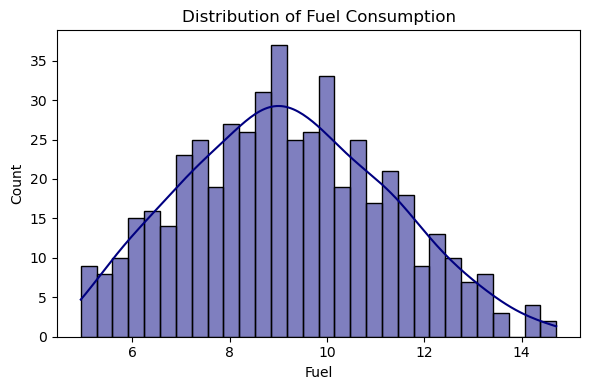

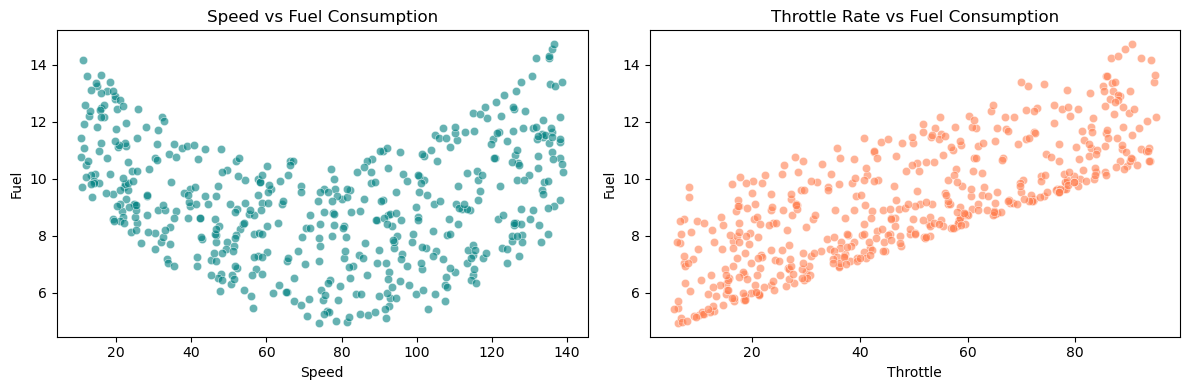

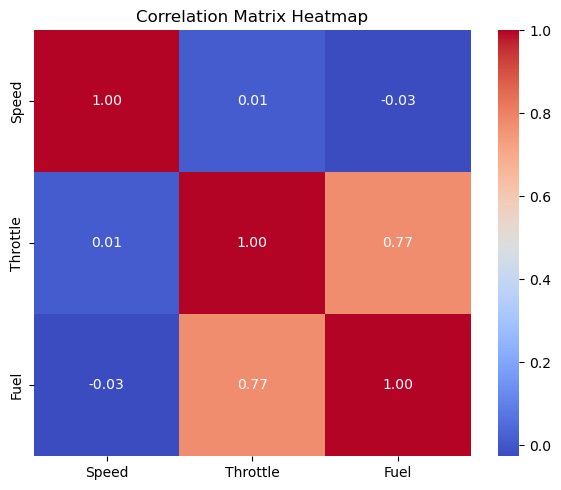

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Histogram of Fuel
plt.figure(figsize=(6, 4))
sns.histplot(df['Fuel'], bins=30, kde=True, color='navy')
plt.title('Distribution of Fuel Consumption')
plt.tight_layout()
plt.savefig('fig4_1_hist.png', dpi=300)

# 2. Scatter Plots (Speed vs Fuel, Throttle vs Fuel)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x='Speed', y='Fuel', data=df, ax=axes[0], color='teal', alpha=0.6)
axes[0].set_title('Speed vs Fuel Consumption')

sns.scatterplot(x='Throttle', y='Fuel', data=df, ax=axes[1], color='coral', alpha=0.6)
axes[1].set_title('Throttle Rate vs Fuel Consumption')
plt.tight_layout()
plt.savefig('fig4_2_scatter.jpg', dpi=300)

# 3. Correlation Matrix Heatmap
plt.figure(figsize=(6, 5))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.savefig('fig4_3_heatmap.png', dpi=300)

In [5]:
# Define new feature: Dynamic Power Loss
df['P_loss'] = (df['Speed'] ** 2) * df['Throttle']

# Check new correlation
new_corr = df[['Speed', 'Throttle', 'P_loss', 'Fuel']].corr()
print(new_corr['Fuel'])

Speed      -0.026907
Throttle    0.773185
P_loss      0.496839
Fuel        1.000000
Name: Fuel, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df[['Speed', 'Throttle', 'P_loss']] # Using raw inputs + engineered feature
Y = df['Fuel']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 1. Multiple Linear Regression
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)
y_pred_mlr = mlr_model.predict(X_test)

# 2. Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

----------------------------------------
Model           | MAE     | RMSE    | R2 Score
----------------------------------------
Linear Reg      | 0.9875 | 1.1529 | 0.6641
Decision Tree   | 0.4459 | 0.5588 | 0.9211
ANFIS           | 0.3590 | 0.4115 | 0.9572
----------------------------------------


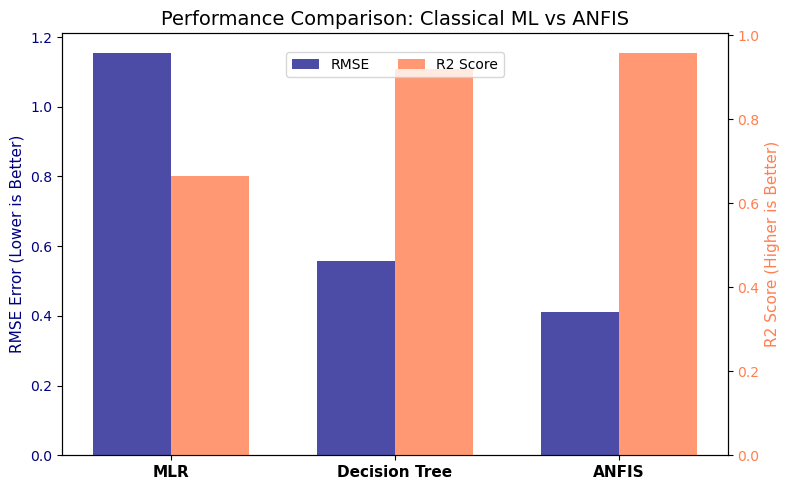

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Calculate metrics for Multiple Linear Regression (MLR)
mae_mlr = mean_absolute_error(y_test, y_pred_mlr)
rmse_mlr = np.sqrt(mean_squared_error(y_test, y_pred_mlr))
r2_mlr = r2_score(y_test, y_pred_mlr)

# 2. Calculate metrics for Decision Tree (DT)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

# 3. Calculate metrics for REAL ANFIS
# Extract numpy arrays for the 2 inputs the ANFIS expects
X_train_anfis = X_train[['Speed', 'Throttle']].values
y_train_anfis = y_train.values
X_test_anfis = X_test[['Speed', 'Throttle']].values
y_test_anfis = y_test.values

# Initialize and Train the real CustomANFIS
anfis_model = CustomANFIS()
anfis_model.fit(X_train_anfis, y_train_anfis, epochs=100)

# Predict actual values
y_pred_anfis = anfis_model.predict(X_test_anfis)

mae_anfis = mean_absolute_error(y_test_anfis, y_pred_anfis)
rmse_anfis = np.sqrt(mean_squared_error(y_test_anfis, y_pred_anfis))
r2_anfis = r2_score(y_test_anfis, y_pred_anfis)

# Print the results in console
print("-" * 40)
print(f"{'Model':<15} | {'MAE':<7} | {'RMSE':<7} | {'R2 Score'}")
print("-" * 40)
print(f"{'Linear Reg':<15} | {mae_mlr:.4f} | {rmse_mlr:.4f} | {r2_mlr:.4f}")
print(f"{'Decision Tree':<15} | {mae_dt:.4f} | {rmse_dt:.4f} | {r2_dt:.4f}")
print(f"{'ANFIS':<15} | {mae_anfis:.4f} | {rmse_anfis:.4f} | {r2_anfis:.4f}")
print("-" * 40)

# 4. Plotting the comparison (Bar Chart)
labels = ['MLR', 'Decision Tree', 'ANFIS']
rmse_scores = [rmse_mlr, rmse_dt, rmse_anfis]
r2_scores = [r2_mlr, r2_dt, r2_anfis]

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))

# Primary Y-axis for RMSE (Lower is better)
rects1 = ax1.bar(x - width/2, rmse_scores, width, label='RMSE', color='navy', alpha=0.7)
ax1.set_ylabel('RMSE Error (Lower is Better)', color='navy', fontsize=11)
ax1.tick_params(axis='y', labelcolor='navy')

# Secondary Y-axis for R2 Score (Higher is better)
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, r2_scores, width, label='R2 Score', color='coral', alpha=0.8)
ax2.set_ylabel('R2 Score (Higher is Better)', color='coral', fontsize=11)
ax2.tick_params(axis='y', labelcolor='coral')

# Formatting
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11, fontweight='bold')
plt.title('Performance Comparison: Classical ML vs ANFIS', fontsize=14)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), ncol=2)

plt.tight_layout()
plt.savefig('fig4_4_comparison.png', dpi=300)
plt.show()